In [1]:
#importing libraries
from sklearn.utils import resample
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split



In [2]:
#Reading csv into dataframe
df=pd.read_csv(r"C:\Users\ddnri\OneDrive\creditcard.csv")
#Printing data frame
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
#shows class imbalance
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
#Handling imbalanced data, Making dataset balanced
x=df.drop('Class',axis=1)
y=df['Class']
sm=SMOTE()
x_res,y_res=sm.fit_resample(x,y)
df1=pd.DataFrame(x_res,columns=x.columns)
df1['Class']=y_res
print(pd.Series(df1['Class']).value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [5]:
#checking null values in each column
df1.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
#Removing Duplicate rows
df1.drop_duplicates(inplace=True)
#Printing column names
df1.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
#Performing Standardisation 
ss=StandardScaler()
df1['Time']=ss.fit_transform(df1[['Time']])
df1['Amount']=ss.fit_transform(df1[['Amount']])
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.812006,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240627,0
1,-1.812006,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.421620,0
2,-1.811986,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.272962,0
3,-1.811986,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122898,0
4,-1.811965,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118283,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,0.619410,-4.169324,4.149556,-6.424487,4.684960,-1.444414,-0.506773,-3.866750,-2.826927,-0.932058,...,3.834683,-1.360443,0.681156,0.017313,0.039939,0.277374,0.392570,1.091746,-0.017079,1
568626,-0.716271,1.234895,0.472018,0.124238,1.088836,0.030490,-0.360902,-0.016393,-0.142927,-0.141527,...,-0.079407,-0.188217,-0.125679,-0.394482,0.674013,-0.377537,0.066355,0.037441,-0.428532,1
568627,-0.528148,-3.269213,2.850422,-3.793983,4.075012,-1.746570,-1.178303,-3.704130,1.327182,-1.885405,...,0.573144,-0.145514,0.070213,-0.445633,-0.103426,-0.133563,-0.449009,0.468704,-0.415063,1
568628,1.128662,-1.321578,1.503618,-3.153668,2.605105,3.411183,-3.041135,-5.874690,-1.953734,-1.160402,...,-0.714269,-0.222646,-5.559055,0.676647,-1.584453,-0.644178,0.836953,0.470243,-0.385349,1


In [8]:
#Handling Outliers using z-score method
for col in df.columns:
    mu=df[col].mean()
    sig=df[col].std()
    df1['z-score']=(df1[col]-mu)/sig
    df1[(df1['z-score']>-3)&(df1['z-score']<3)]
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,z-score
0,-1.812006,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.240627,0,-0.041599
1,-1.812006,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.421620,0,-0.041599
2,-1.811986,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.272962,0,-0.041599
3,-1.811986,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.122898,0,-0.041599
4,-1.811965,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.118283,0,-0.041599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,0.619410,-4.169324,4.149556,-6.424487,4.684960,-1.444414,-0.506773,-3.866750,-2.826927,-0.932058,...,-1.360443,0.681156,0.017313,0.039939,0.277374,0.392570,1.091746,-0.017079,1,24.039010
568626,-0.716271,1.234895,0.472018,0.124238,1.088836,0.030490,-0.360902,-0.016393,-0.142927,-0.141527,...,-0.188217,-0.125679,-0.394482,0.674013,-0.377537,0.066355,0.037441,-0.428532,1,24.039010
568627,-0.528148,-3.269213,2.850422,-3.793983,4.075012,-1.746570,-1.178303,-3.704130,1.327182,-1.885405,...,-0.145514,0.070213,-0.445633,-0.103426,-0.133563,-0.449009,0.468704,-0.415063,1,24.039010
568628,1.128662,-1.321578,1.503618,-3.153668,2.605105,3.411183,-3.041135,-5.874690,-1.953734,-1.160402,...,-0.222646,-5.559055,0.676647,-1.584453,-0.644178,0.836953,0.470243,-0.385349,1,24.039010


In [9]:
#Handling Outliers using iqr method
for col1 in df.columns:
    q1=df[col1].quantile(0.25)
    q3=df[col1].quantile(0.75)
    iqr=q3-q1
    upp=q3+1.5*iqr
    low=q1-1.5*iqr
    df[(df[col1]>=low)&(df[col1]<=upp)]
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


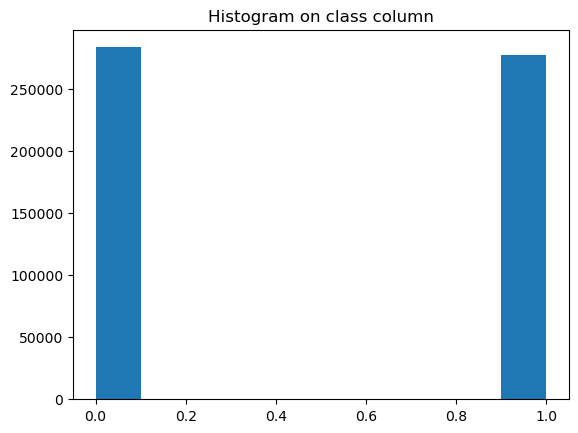

In [10]:
#Ploting a histogram on class column
plt.hist(df1['Class'])
plt.title("Histogram on class column")
plt.show()

In [11]:
#Feature Selection

In [12]:
x = df1.drop(columns=['Class','z-score'])
y = df1['Class']

In [13]:
y

0         0
1         0
2         0
3         0
4         0
         ..
568625    1
568626    1
568627    1
568628    1
568629    1
Name: Class, Length: 560208, dtype: int64

In [14]:
x_sample, _, y_sample, _ = train_test_split(
    x, y,
    train_size=10000,
    random_state=42,
    stratify=y          # <-- this makes it stratified
)
y_sample=y_sample.astype(int)

# Verify class balance is preserved
print(y_sample.value_counts())

Class
0    5056
1    4944
Name: count, dtype: int64


In [15]:
model = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)


In [16]:
fs_seq = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=15,
    direction='forward',
    scoring='roc_auc',
    cv=2,
    n_jobs=-1
)

In [20]:
fs_seq.fit(x_sample, y_sample)

,estimator,LogisticRegre...solver='saga')
,n_features_to_select,15
,tol,None
,direction,'forward'
,scoring,'roc_auc'
,cv,2
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:
sfs_features = x.columns[fs_seq.get_support()].tolist()


In [24]:
print(sfs_features)

['Time', 'V3', 'V4', 'V6', 'V7', 'V8', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V22']


In [247]:
#correlation matrix
df_selected=df1[sfs_features]
plt.figure(figsize=(12,10))
correlation_matrix=df_selected.corr()
print(correlation_matrix)

          Time        V3        V4        V6        V7        V8       V10  \
Time  1.000000  0.175049 -0.226934  0.140578  0.250004 -0.207882  0.243514   
V3    0.175049  1.000000 -0.778506  0.533980  0.893106 -0.343655  0.846448   
V4   -0.226934 -0.778506  1.000000 -0.488893 -0.736146  0.180431 -0.819669   
V6    0.140578  0.533980 -0.488893  1.000000  0.393378 -0.541963  0.480638   
V7    0.250004  0.893106 -0.736146  0.393378  1.000000 -0.118692  0.875963   
V8   -0.207882 -0.343655  0.180431 -0.541963 -0.118692  1.000000 -0.151430   
V10   0.243514  0.846448 -0.819669  0.480638  0.875963 -0.151430  1.000000   
V11  -0.334245 -0.732007  0.819645 -0.545927 -0.672097  0.259147 -0.825823   
V12   0.282688  0.766890 -0.853608  0.540708  0.747818 -0.235715  0.896970   
V14   0.190441  0.673726 -0.820650  0.587120  0.575358 -0.284241  0.787104   
V16   0.260276  0.741401 -0.759319  0.495463  0.774522 -0.290958  0.875773   
V17   0.264104  0.751375 -0.739434  0.477568  0.802093 -0.325706

<Figure size 1200x1000 with 0 Axes>

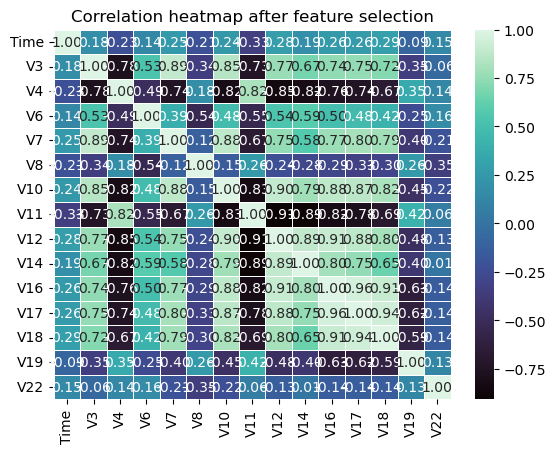

In [249]:
#heatmap
sns.heatmap(correlation_matrix,annot=True,cmap='mako',fmt=".2f",linewidths=0.5)
plt.title("Correlation heatmap after feature selection")
plt.show()

In [25]:
#logistic regression

In [227]:
#importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,mean_squared_error, mean_absolute_error,accuracy_score,precision_score,f1_score, recall_score,r2_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [228]:
logreg = LogisticRegression()

In [229]:
X = df1[sfs_features]
y = df1['Class']

In [230]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [231]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [232]:
# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],   # safe option
    'solver': ['lbfgs']  # stable + fast
}

In [233]:
# Grid Search
grid = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [234]:
X_train, X_test, y_train, y_test

(            Time         V3         V4        V6         V7         V8  \
 547339  0.453582  -3.883545   6.430396  0.210645  -0.984462   0.518886   
 156890  0.440845   2.385690  -0.109522 -0.263504   0.535705  -0.241031   
 426058 -0.716354   0.014304   1.383979 -0.343982  -0.291555  -0.048732   
 340819 -1.365225 -24.630091  11.787783 -2.640486 -17.993934   2.658404   
 291081  1.340701  -2.893644   1.716952 -1.284551  -0.058296  -0.287343   
 ...          ...        ...        ...       ...        ...        ...   
 110703 -0.326822  -0.426582  -0.404109 -0.737552   0.341009  -0.307407   
 260136  1.479299  -0.605170  -0.788264 -0.203064   0.861209   0.067349   
 369063  0.306595 -18.329045  10.099153  2.704118 -26.120185 -20.414696   
 132427 -0.160707  -0.721776   0.071903  3.635628  -0.821682   0.929256   
 122429 -0.231418   1.326391  -1.345201 -0.683284   0.856022  -0.178265   
 
               V10       V11        V12        V14       V16        V17  \
 547339  -2.380892  3.3

In [235]:
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [236]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)

In [237]:
y_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(112042,))

In [238]:
accuracy_score(y_test, y_pred) 
# The ratio of correct predictions out of the total predictions made by the model.


0.9769372199710823

In [239]:
precision_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all values predicted 

0.988485990981001

In [240]:
recall_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all actual positive values.

0.9646322548064784

In [241]:
f1_score(y_test, y_pred)


0.9764134582032605

In [242]:
print(confusion_matrix(y_test, y_pred))

[[55973   623]
 [ 1961 53485]]


In [243]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56596
           1       0.99      0.96      0.98     55446

    accuracy                           0.98    112042
   macro avg       0.98      0.98      0.98    112042
weighted avg       0.98      0.98      0.98    112042



In [244]:
print("logistic regression ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc score

logistic regression ROC-AUC: 0.9768122048645439


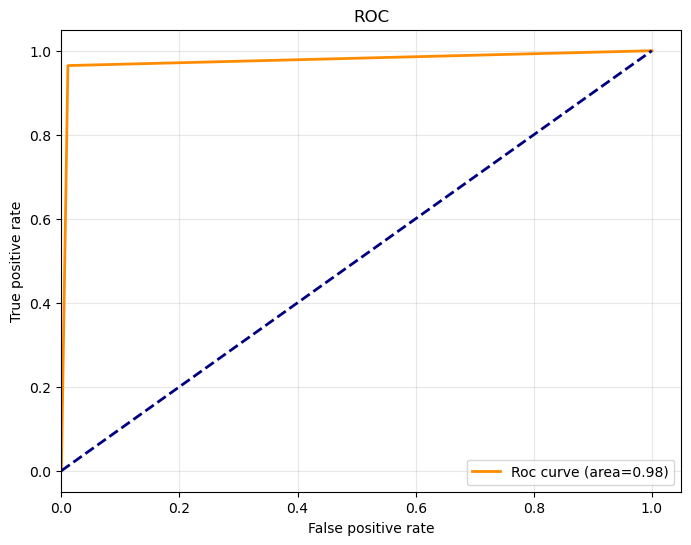

In [245]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [44]:
#K-Nearest Neighbour

In [203]:
#Importing libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn .model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler


In [204]:
X = df1[sfs_features]
y = df1['Class']

In [205]:
X,y

(            Time        V3        V4        V6        V7        V8       V10  \
 0      -1.812006  2.536347  1.378155  0.462388  0.239599  0.098698  0.090794   
 1      -1.812006  0.166480  0.448154 -0.082361 -0.078803  0.085102 -0.166974   
 2      -1.811986  1.773209  0.379780  1.800499  0.791461  0.247676  0.207643   
 3      -1.811986  1.792993 -0.863291  1.247203  0.237609  0.377436 -0.054952   
 4      -1.811965  1.548718  0.403034  0.095921  0.592941 -0.270533  0.753074   
 ...          ...       ...       ...       ...       ...       ...       ...   
 568625  0.619410 -6.424487  4.684960 -0.506773 -3.866750 -2.826927 -1.113463   
 568626 -0.716271  0.124238  1.088836 -0.360902 -0.016393 -0.142927 -0.216772   
 568627 -0.528148 -3.793983  4.075012 -1.178303 -3.704130  1.327182 -4.459132   
 568628  1.128662 -3.153668  2.605105 -3.041135 -5.874690 -1.953734 -3.117073   
 568629 -0.038469 -5.554946  3.858338 -1.752338 -5.345927  2.327436 -5.821469   
 
              V11       V1

In [206]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [207]:
#feature scaling


In [208]:
scaler = StandardScaler()

In [209]:
X_train = scaler.fit_transform(X_train)   
X_test = scaler.transform(X_test)         

In [210]:
#Hyper parameter tuning

In [211]:
param_grid = {
    'n_neighbors': [5, 15,25,35,50],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [212]:
X_small, _, y_small, _ = train_test_split(X_train, y_train,
                                           train_size=0.01,
                                           random_state=42)

grid = RandomizedSearchCV(KNeighborsClassifier(), param_grid,
                          n_iter=3, cv=2,
                          scoring='roc_auc', n_jobs=-1)
grid.fit(X_small, y_small)
print("Best params:", grid.best_params_)

Best params: {'weights': 'distance', 'n_neighbors': 35, 'metric': 'manhattan'}


In [213]:
#Hyperparameter tuning result=50

In [214]:
knn = KNeighborsClassifier(n_neighbors=50)

In [215]:
knn.fit(X_train, y_train)

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [216]:
y_pred = knn.predict(X_test)

In [217]:
y_test

418121    1
465843    1
259536    0
254133    0
498914    1
         ..
80345     0
430722    1
2440      0
141022    0
177185    0
Name: Class, Length: 112042, dtype: int64

In [218]:
y_pred


array([1, 1, 0, ..., 0, 0, 0], shape=(112042,))

In [219]:
accuracy_score(y_test, y_pred) # The ratio of correct predictions out of the total predictions made by the model.


0.9954570607450778

In [220]:
precision_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all values predicted 

0.9909034045214905

In [221]:
recall_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all actual positive values.

1.0

In [222]:
f1_score(y_test, y_pred)

0.9954309207278211

In [223]:
print(confusion_matrix(y_test, y_pred))

[[56087   509]
 [    0 55446]]


In [224]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56596
           1       0.99      1.00      1.00     55446

    accuracy                           1.00    112042
   macro avg       1.00      1.00      1.00    112042
weighted avg       1.00      1.00      1.00    112042



In [225]:
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc-score

KNN ROC-AUC: 0.9955032157749664


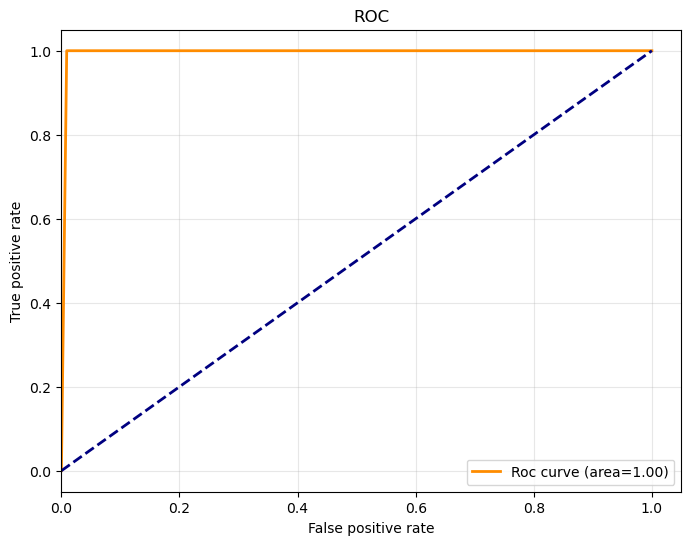

In [226]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [68]:
#Support Vector Machine

In [178]:
#Importing libraries
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [179]:
X = df1[sfs_features]
y = df1['Class']

In [180]:
X,y

(            Time        V3        V4        V6        V7        V8       V10  \
 0      -1.812006  2.536347  1.378155  0.462388  0.239599  0.098698  0.090794   
 1      -1.812006  0.166480  0.448154 -0.082361 -0.078803  0.085102 -0.166974   
 2      -1.811986  1.773209  0.379780  1.800499  0.791461  0.247676  0.207643   
 3      -1.811986  1.792993 -0.863291  1.247203  0.237609  0.377436 -0.054952   
 4      -1.811965  1.548718  0.403034  0.095921  0.592941 -0.270533  0.753074   
 ...          ...       ...       ...       ...       ...       ...       ...   
 568625  0.619410 -6.424487  4.684960 -0.506773 -3.866750 -2.826927 -1.113463   
 568626 -0.716271  0.124238  1.088836 -0.360902 -0.016393 -0.142927 -0.216772   
 568627 -0.528148 -3.793983  4.075012 -1.178303 -3.704130  1.327182 -4.459132   
 568628  1.128662 -3.153668  2.605105 -3.041135 -5.874690 -1.953734 -3.117073   
 568629 -0.038469 -5.554946  3.858338 -1.752338 -5.345927  2.327436 -5.821469   
 
              V11       V1

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [182]:
#Feature scaling

In [183]:
scaler = StandardScaler()


In [184]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [185]:
#Hyperparameter tuning

In [78]:
kernels = ['linear', 'rbf', 'poly']

print("Kernel Comparison:")
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"Kernel: {k}, MSE: {mse}")

Kernel Comparison:
Kernel: linear, MSE: 0.022928901661876794
Kernel: rbf, MSE: 0.01070134413880509
Kernel: poly, MSE: 0.012798771889113011


In [186]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']
    
}

In [187]:
grid = GridSearchCV(SVC(), param_grid, cv=2, scoring='accuracy', n_jobs=-1)

In [188]:
X_svm, _, y_svm, _ = train_test_split(
    X_train, y_train,
    train_size=0.02,
    random_state=42
)

In [189]:
grid.fit(X_svm, y_svm)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [190]:
print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'kernel': 'rbf'}


In [191]:
best_model=grid.best_estimator_

In [192]:
y_pred = best_model.predict(X_test)


In [193]:
y_test

418121    1
465843    1
259536    0
254133    0
498914    1
         ..
80345     0
430722    1
2440      0
141022    0
177185    0
Name: Class, Length: 112042, dtype: int64

In [194]:
y_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(112042,))

In [195]:
accuracy_score(y_test, y_pred) # The ratio of correct predictions out of the total predictions made by the model.


0.9842291283625784

In [196]:
precision_score(y_test, y_pred)
# The ratio of correctly predicted positive values out of all values predicted 

0.9924407830761609

In [197]:
recall_score(y_test, y_pred) # The ratio of correctly predicted positive values out of all actual positive values.

0.9755618078851496

In [198]:
f1_score(y_test, y_pred)

0.9839289124957935

In [199]:
print(confusion_matrix(y_test, y_pred))

[[56184   412]
 [ 1355 54091]]


In [200]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     56596
           1       0.99      0.98      0.98     55446

    accuracy                           0.98    112042
   macro avg       0.98      0.98      0.98    112042
weighted avg       0.98      0.98      0.98    112042



In [201]:
print("SVM ROC-AUC:", roc_auc_score(y_test, y_pred)) #roc-auc-score

SVM ROC-AUC: 0.9841410707388147


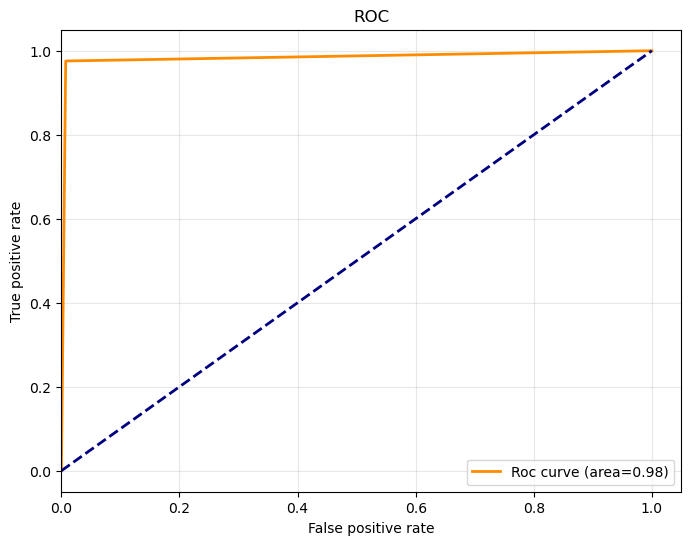

In [202]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'Roc curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()